## Validation of likelihood - sanity check

In this notebook I check contributions of the different likelihood terms 
to make sure that they have reasonable (comparable) values. 

In [36]:
import numpy as np 
import matplotlib.pyplot as plt

from optimizer import HessProjLikelihood

In [37]:
# Read data 
# Import color and magnitude distributions for the defined populations in the modeled volume 

def read_cmf_data(pops=['wd','ms','ums','lms','g'],source_dir='./data/1kpc/'):

    coldata_d = {pop:{'SCD_S0':[],'SCD_S1':[],'NSCD_S0':[],'NSCD_S1':[]} for pop in pops}
    magdata_d = {pop:{'SMD_S0':[],'SMD_S1':[],'NSMD_S0':[],'NSMD_S1':[]} for pop in pops}

    for pop in pops:
        cdf = np.loadtxt(source_dir + 'coldist/nsdf_' + pop + '.txt')
        coldata_d[pop]['SCD_S0'] = cdf[:,2]
        coldata_d[pop]['SCD_S1'] = cdf[:,3]
        coldata_d[pop]['NSCD_S0'] = cdf[:,4]
        coldata_d[pop]['NSCD_S1'] = cdf[:,5]

        mdf = np.loadtxt(source_dir + 'magdist/nsdf_' + pop + '.txt')
        magdata_d[pop]['SMD_S0'] = mdf[:,2]
        magdata_d[pop]['SMD_S1'] = mdf[:,3]
        magdata_d[pop]['NSMD_S0'] = mdf[:,4]
        magdata_d[pop]['NSMD_S1'] = mdf[:,5]

    coldata_d['LOW'] = np.round(cdf[:,0],2)
    coldata_d['HIGH'] = np.round(cdf[:,1],2)

    magdata_d['LOW'] = np.round(mdf[:,0],2)
    magdata_d['HIGH'] = np.round(mdf[:,1],2)

    return coldata_d, magdata_d


def read_cmf_model(pops=['wd','ms','ums','lms','g'],source_dir='./output/CMDF/',model='default_model'):

    # Read model 
    coldata_m = {pop:{'SCD':[],'NSCD':[]} for pop in pops}
    magdata_m = {pop:{'SMD':[],'NSMD':[]} for pop in pops}

    for pop in pops:
        cdf = np.loadtxt(source_dir + 'cdf_' + model + '_' + pop + '.txt')
        coldata_m[pop]['SCD'] = cdf[:,0]
        coldata_m[pop]['NSCD'] = cdf[:,1]

        mdf = np.loadtxt(source_dir + 'mdf_' + model + '_' + pop + '.txt')
        magdata_m[pop]['SMD'] = mdf[:,0]
        magdata_m[pop]['NSMD'] = mdf[:,1]

    return coldata_m, magdata_m


In [38]:
pops=['wd','ms','ums','lms','g']

coldata_d, magdata_d = read_cmf_data()
coldata_m, magdata_m = read_cmf_model(model='pop5_basti') # predictions for MCMC best parameters

In [39]:
# Max indices where col and mag distributions will be cut off
ind_c = 100
ind_m = 117

# Likelihood hyperparameters
# see optimizer.HessProjLikelihood for details
sigma_shape2 = {
    'wd':{'cdf':0.02,'mdf':0.01},
    'g':{'cdf':0.02,'mdf':0.01},
    'ums':{'cdf':0.02,'mdf':0.01},
    'ms':{'cdf':0.02,'mdf':0.01},
    'lms':{'cdf':0.02,'mdf':0.01},
    }
epsilon_count = {
    'wd':0.05,
    'g':0.05,
    'ums':0.05,
    'ms':0.05,
    'lms':0.05,
}

# Define dicts with CD and MD from the data and model

eps = 1e-5 # to avoid zero division
hessproj_data = {pop:{'cdf':coldata_d[pop]['SCD_S0'][:ind_c]+eps,'ncdf':coldata_d[pop]['NSCD_S1'][:ind_c]+eps,
                      'mdf':magdata_d[pop]['SMD_S0'][:ind_m]+eps,'nmdf':magdata_d[pop]['NSMD_S1'][:ind_m]+eps} for pop in pops}

hessproj_model = {pop:{'cdf':coldata_m[pop]['SCD'][:ind_c]+eps,'ncdf':coldata_m[pop]['NSCD'][:ind_c]+eps,
                       'mdf':magdata_m[pop]['SMD'][:ind_m]+eps,'nmdf':magdata_m[pop]['NSMD'][:ind_m]+eps,
                       'n_pop':coldata_m[pop]['SCD'][:ind_c].sum()} for pop in pops}

# Initialize likelihood
lh = HessProjLikelihood(sigma_shape2,epsilon_count,bin_width={'cdf':0.02,'mdf':0.2})

logL_shape_CD: -1.96  -> f =  0.55
logL_shape_MD: -0.69  -> f =  0.2
logL_count: -0.89  -> f =  0.25
N_data = 110530
N_model = 118439


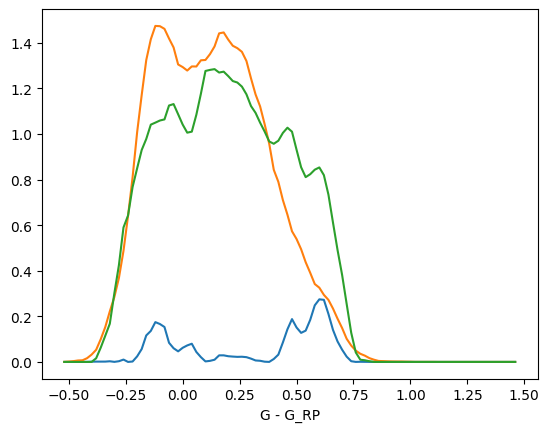

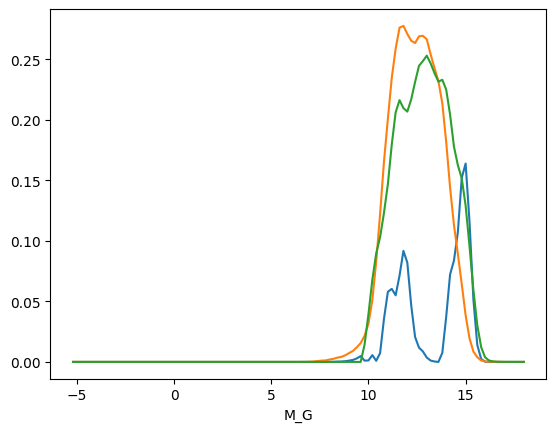

In [40]:
# Check CD/MD and likelihood per bin

pop = 'wd'  

l_shape_cd, l_shape_per_bin = lh.lproj_shape(hessproj_model,pop,proj_type='cdf')

plt.figure()
plt.plot(coldata_d['LOW'][:ind_c],l_shape_per_bin)
plt.plot(coldata_d['LOW'][:ind_c],coldata_d[pop]['NSCD_S1'][:ind_c])
plt.plot(coldata_d['LOW'][:ind_c],coldata_m[pop]['NSCD'][:ind_c])
plt.xlabel('G - G_RP')

l_shape_md, l_shape_per_bin = lh.lproj_shape(hessproj_model,pop,proj_type='mdf')

plt.figure()
plt.plot(magdata_d['LOW'][:ind_m],l_shape_per_bin)
plt.plot(magdata_d['LOW'][:ind_m],magdata_d[pop]['NSMD_S1'][:ind_m])
plt.plot(magdata_d['LOW'][:ind_m],magdata_m[pop]['NSMD'][:ind_m])
plt.xlabel('M_G')

l_count, counts = lh.lproj_count(hessproj_model,pop)
l_pop = l_shape_cd + l_shape_md + l_count

print('logL_shape_CD:', round(l_shape_cd,2), ' -> f = ', round(l_shape_cd/l_pop,2))
print('logL_shape_MD:', round(l_shape_md,2), ' -> f = ',round(l_shape_md/l_pop,2))
print('logL_count:', round(l_count,2), ' -> f = ',round(l_count/l_pop,2))
print('N_data =', int(round(hessproj_data[pop]['cdf'].sum(),0)))
print('N_model =', int(round(hessproj_model[pop]['cdf'].sum(),0)))

In [41]:
# And check statistics for all populations

l_tot = 0 
l_fr = []

for pop in pops:

    print('Population: ' + pop)

    l_shape_cd, l_shape_per_bin = lh.lproj_shape(hessproj_model,pop,proj_type='cdf')

    nm = hessproj_model[pop]['cdf'].sum()
    nd = hessproj_data[pop]['cdf'].sum()

    print('N_data =', int(round(nd,0)))
    print('N_model =', int(round(nm,0)))
    print('N_model/N_data - 1 =', round(nm/nd - 1,3)) 

    l_shape_md, l_shape_per_bin = lh.lproj_shape(hessproj_model,pop,proj_type='mdf')
    l_count, counts = lh.lproj_count(hessproj_model,pop)

    l_pop = l_shape_cd + l_shape_md + l_count

    print('logL_shape_CD:', round(l_shape_cd,2), ' -> f = ', round(l_shape_cd/l_pop,2))
    print('logL_shape_MD:', round(l_shape_md,2), ' -> f = ',round(l_shape_md/l_pop,2))
    print('logL_count:', round(l_count,2), ' -> f = ',round(l_count/l_pop,2),'\n')

    l_tot += l_pop
    l_fr.append(l_pop)

print('logL_pop_i/logL_tot:',np.round(l_fr/l_tot,2))
print('logL_tot =',round(l_tot,2))

Population: wd
N_data = 110530
N_model = 118439
N_model/N_data - 1 = 0.072
logL_shape_CD: -1.96  -> f =  0.55
logL_shape_MD: -0.69  -> f =  0.2
logL_count: -0.89  -> f =  0.25 

Population: ms
N_data = 2167450
N_model = 2095111
N_model/N_data - 1 = -0.033
logL_shape_CD: -2.17  -> f =  0.82
logL_shape_MD: -0.23  -> f =  0.09
logL_count: -0.24  -> f =  0.09 

Population: ums
N_data = 452743
N_model = 438546
N_model/N_data - 1 = -0.031
logL_shape_CD: -14.87  -> f =  0.94
logL_shape_MD: -0.82  -> f =  0.05
logL_count: -0.21  -> f =  0.01 

Population: lms
N_data = 4809943
N_model = 4562178
N_model/N_data - 1 = -0.052
logL_shape_CD: -2.54  -> f =  0.54
logL_shape_MD: -1.56  -> f =  0.33
logL_count: -0.59  -> f =  0.13 

Population: g
N_data = 84509
N_model = 76983
N_model/N_data - 1 = -0.089
logL_shape_CD: -6.59  -> f =  0.56
logL_shape_MD: -3.35  -> f =  0.28
logL_count: -1.9  -> f =  0.16 

logL_pop_i/logL_tot: [0.09 0.07 0.41 0.12 0.31]
logL_tot = -38.6
